# face mask detection


In [1]:
import os, glob, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

objc[31565]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1292e43a8) and /opt/anaconda3/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x1523303a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[31565]: Class AVFAudioReceiver is implemented in both /opt/anaconda3/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1292e43f8) and /opt/anaconda3/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x1523303f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('device:', device)

device: mps


## load data

In [3]:
DATA_DIR = 'face_mask_detection_dataset'

classes = ['with_mask', 'without_mask']
cls_idx = {c: i for i, c in enumerate(classes)}

items = []
for c in classes:
    for p in glob.glob(os.path.join(DATA_DIR, c, '*.jpg')):
        items.append((p, cls_idx[c]))
random.shuffle(items)
print('total images', len(items))
print({c: sum(1 for _, y in items if y == cls_idx[c]) for c in classes})

total images 7553
{'with_mask': 3725, 'without_mask': 3828}


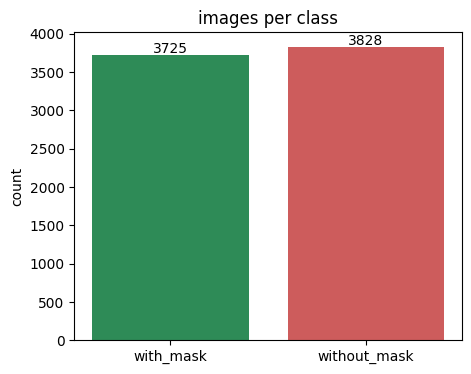

imbalance ratio 1.03 to 1


In [4]:
counts = [sum(1 for _, y in items if y == i) for i in range(len(classes))]
plt.figure(figsize=(5, 4))
plt.bar(classes, counts, color=['seagreen', 'indianred'])
plt.title('images per class'); plt.ylabel('count')
for i, v in enumerate(counts):
    plt.text(i, v + 30, str(v), ha='center')
plt.show()
print('imbalance ratio %.2f to 1' % (max(counts) / min(counts)))

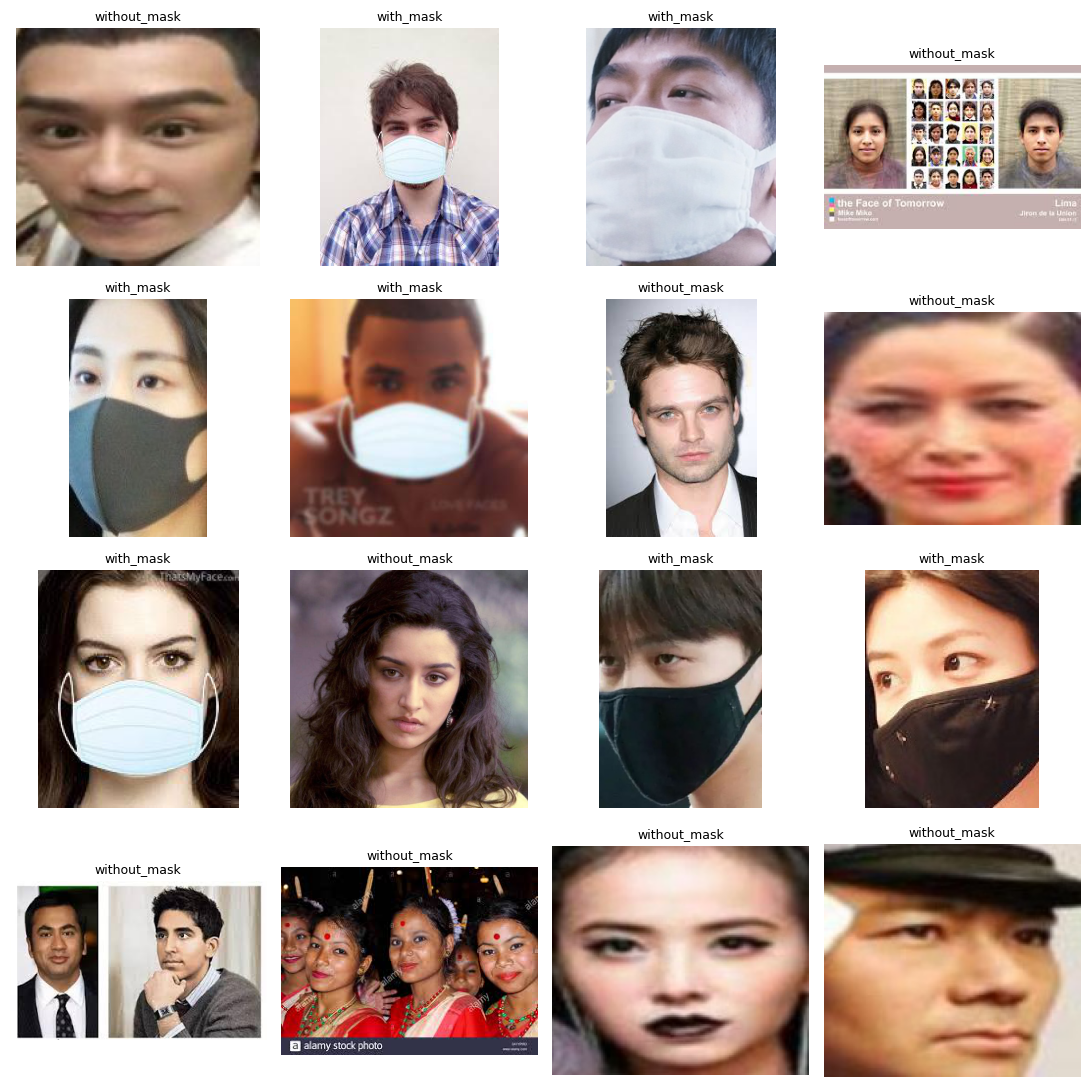

In [5]:
# 4x4 grid of samples
fig, ax = plt.subplots(4, 4, figsize=(11, 11))
for a in ax.ravel():
    p, y = random.choice(items)
    a.imshow(Image.open(p).convert('RGB'))
    a.set_title(classes[y], fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

## transforms

In [ ]:
IMN_MEAN = [0.485, 0.456, 0.406]
IMN_STD  = [0.229, 0.224, 0.225]

cnn_train_tf = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
])
cnn_eval_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

mob_train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMN_MEAN, IMN_STD),
])
mob_eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMN_MEAN, IMN_STD),
])

class MaskDS(Dataset):
    def __init__(self, data, tf):
        self.data = data; self.tf = tf
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        p, y = self.data[i]
        return self.tf(Image.open(p).convert('RGB')), y

## split

70 / 15 / 15 stratified, fixed seed.

In [7]:
labels = [y for _, y in items]
trainval, test = train_test_split(items, test_size=0.15, stratify=labels, random_state=SEED)
tv_labels = [y for _, y in trainval]
train, val = train_test_split(trainval, test_size=0.1765, stratify=tv_labels, random_state=SEED)
print('train', len(train), ' val', len(val), ' test', len(test))

train 5286  val 1134  test 1133


In [ ]:
BATCH = 64

cnn_tr_dl = DataLoader(MaskDS(train, cnn_train_tf), batch_size=BATCH, shuffle=True)
cnn_va_dl = DataLoader(MaskDS(val,   cnn_eval_tf),  batch_size=BATCH)
cnn_te_dl = DataLoader(MaskDS(test,  cnn_eval_tf),  batch_size=BATCH)

mob_tr_dl = DataLoader(MaskDS(train, mob_train_tf), batch_size=BATCH, shuffle=True)
mob_va_dl = DataLoader(MaskDS(val,   mob_eval_tf),  batch_size=BATCH)
mob_te_dl = DataLoader(MaskDS(test,  mob_eval_tf),  batch_size=BATCH)
print('loaders ready')

loaders ready


In [ ]:
def fit(model, tr_dl, va_dl, epochs, lr, ckpt):
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {'tr': [], 'va': [], 'acc': []}
    best = 0.0
    for ep in range(1, epochs + 1):
        model.train(); tl = 0.0; n = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            tl += loss.item()*len(yb); n += len(yb)
        model.eval(); vl = 0.0; m = 0; c = 0
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                vl += crit(out, yb).item()*len(yb); m += len(yb)
                c += (out.argmax(1) == yb).sum().item()
        tl /= n; vl /= m; acc = c / m
        hist['tr'].append(tl); hist['va'].append(vl); hist['acc'].append(acc)
        if acc > best:
            best = acc
            torch.save(model.state_dict(), ckpt)
        print(f'ep {ep:2d}  tr_loss {tl:.3f}  va_loss {vl:.3f}  va_acc {acc:.3f}')
    print('best val acc', round(best, 4))
    return hist

def predict(model, dl):
    model.eval(); P = []; Y = []
    with torch.no_grad():
        for xb, yb in dl:
            P.append(model(xb.to(device)).argmax(1).cpu().numpy())
            Y.append(yb.numpy())
    return np.concatenate(P), np.concatenate(Y)

## model 1: cnn from scratch

In [ ]:
CNN_LR = 1e-3
CNN_EPOCHS = 12

def blk(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o),
                         nn.ReLU(), nn.MaxPool2d(2))

class MaskCNN(nn.Module):
    def __init__(self, n_cls=2):
        super().__init__()
        self.feat = nn.Sequential(blk(3, 32), blk(32, 64), blk(64, 128), blk(128, 128))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(128, n_cls))
    def forward(self, x):
        return self.head(self.feat(x))

cnn = MaskCNN().to(device)
cnn_hist = fit(cnn, cnn_tr_dl, cnn_va_dl, CNN_EPOCHS, CNN_LR, 'best_cnn_mask.pt')

ep  1  tr_loss 0.493  va_loss 0.492  va_acc 0.776


ep  2  tr_loss 0.356  va_loss 0.329  va_acc 0.870


ep  3  tr_loss 0.267  va_loss 0.249  va_acc 0.887


ep  4  tr_loss 0.234  va_loss 0.448  va_acc 0.825


ep  5  tr_loss 0.201  va_loss 0.324  va_acc 0.854


...

ep  8  tr_loss 0.160  va_loss 0.336  va_acc 0.859


ep  9  tr_loss 0.146  va_loss 0.144  va_acc 0.952


ep 10  tr_loss 0.158  va_loss 0.169  va_acc 0.929


ep 11  tr_loss 0.139  va_loss 0.218  va_acc 0.921


ep 12  tr_loss 0.127  va_loss 0.138  va_acc 0.951
best val acc 0.9524


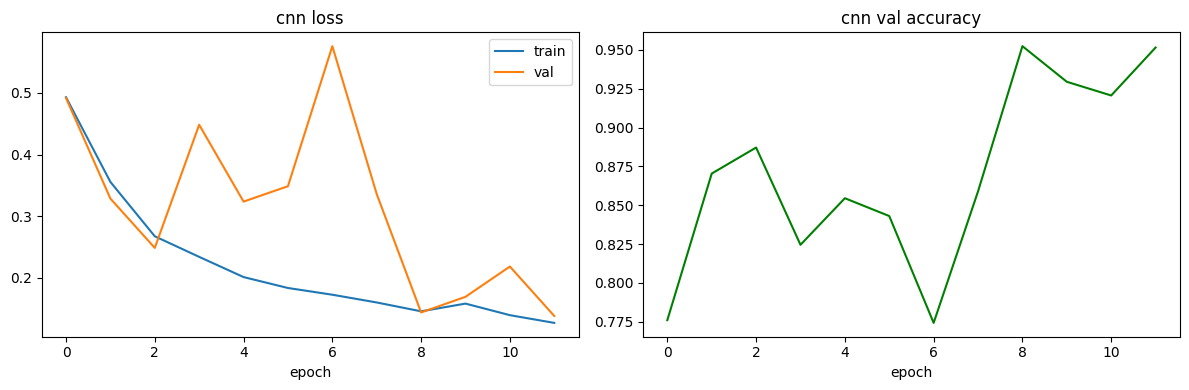

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(cnn_hist['tr'], label='train'); ax[0].plot(cnn_hist['va'], label='val')
ax[0].set_title('cnn loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(cnn_hist['acc'], color='green')
ax[1].set_title('cnn val accuracy'); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

## evaluate cnn

cnn test accuracy: 0.9568
              precision    recall  f1-score   support

   with_mask       0.96      0.95      0.96       559
without_mask       0.95      0.96      0.96       574

    accuracy                           0.96      1133
   macro avg       0.96      0.96      0.96      1133
weighted avg       0.96      0.96      0.96      1133



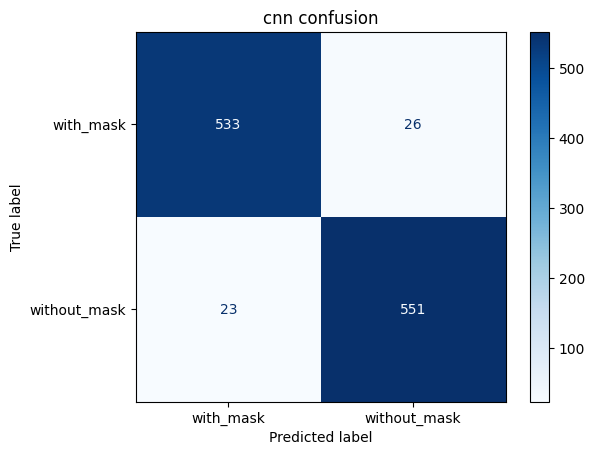

In [12]:
cnn.load_state_dict(torch.load('best_cnn_mask.pt', map_location=device))
cnn_pred, y_te = predict(cnn, cnn_te_dl)
cnn_acc = accuracy_score(y_te, cnn_pred)
print('cnn test accuracy:', round(cnn_acc, 4))
print(classification_report(y_te, cnn_pred, target_names=classes))

ConfusionMatrixDisplay(confusion_matrix(y_te, cnn_pred), display_labels=classes).plot(cmap='Blues')
plt.title('cnn confusion'); plt.show()

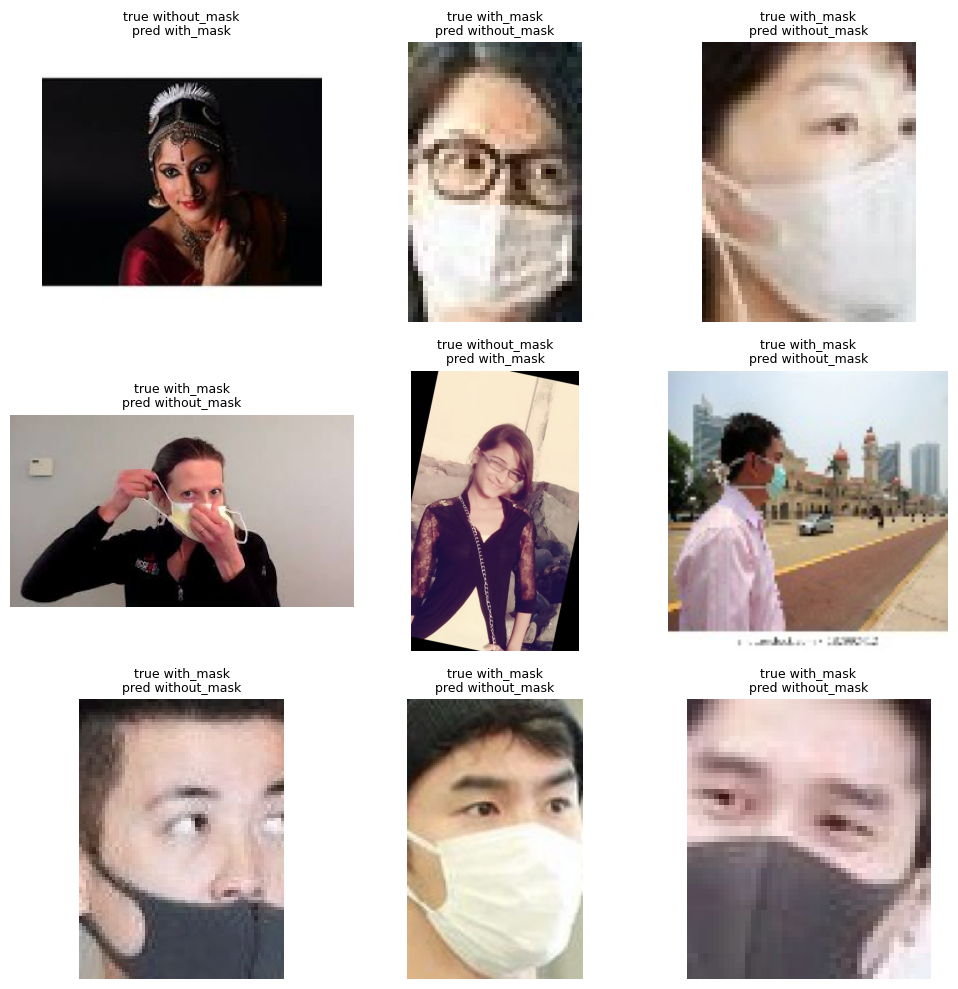

In [ ]:
wrong = np.where(cnn_pred != y_te)[0][:9]
fig, ax = plt.subplots(3, 3, figsize=(10, 10))
ax = ax.ravel()
for k, idx in enumerate(wrong):
    p, y = test[idx]
    ax[k].imshow(Image.open(p).convert('RGB'))
    ax[k].set_title(f'true {classes[y]}\npred {classes[cnn_pred[idx]]}', fontsize=9)
    ax[k].axis('off')
for k in range(len(wrong), 9): ax[k].axis('off')
plt.tight_layout(); plt.show()

## model 2: mobilenetv2 transfer learning

In [14]:
MOB_LR = 1e-3
MOB_EPOCHS = 6

mob = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
for p in mob.parameters():
    p.requires_grad = False
mob.classifier[1] = nn.Linear(mob.last_channel, len(classes))   # new trainable head
mob = mob.to(device)

mob_hist = fit(mob, mob_tr_dl, mob_va_dl, MOB_EPOCHS, MOB_LR, 'best_mobilenet_mask.pt')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/goley/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth



  0%|          | 0.00/13.6M [00:00<?, ?B/s]


 21%|██        | 2.88M/13.6M [00:00<00:00, 30.1MB/s]


 78%|███████▊  | 10.6M/13.6M [00:00<00:00, 58.2MB/s]


100%|██████████| 13.6M/13.6M [00:00<00:00, 59.7MB/s]

...

ep  2  tr_loss 0.124  va_loss 0.081  va_acc 0.984


ep  3  tr_loss 0.110  va_loss 0.066  va_acc 0.985


ep  4  tr_loss 0.085  va_loss 0.072  va_acc 0.981


ep  5  tr_loss 0.083  va_loss 0.052  va_acc 0.987


ep  6  tr_loss 0.078  va_loss 0.051  va_acc 0.989
best val acc 0.9894


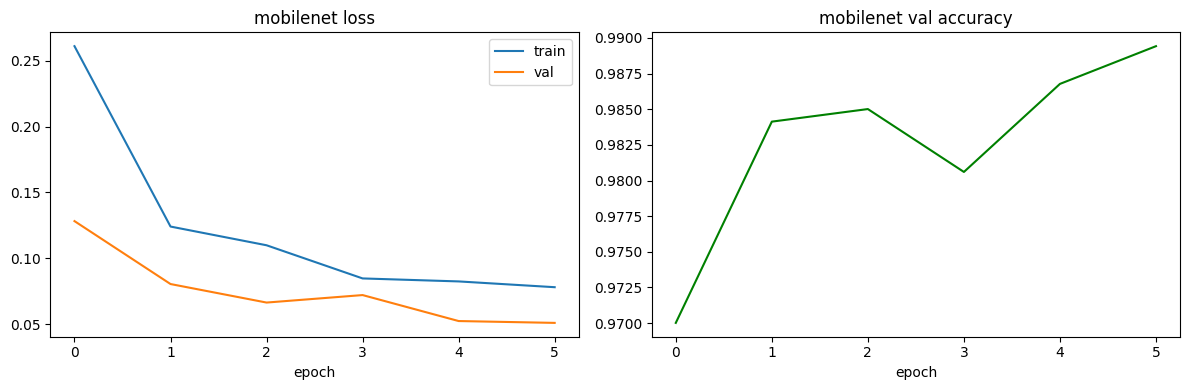

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(mob_hist['tr'], label='train'); ax[0].plot(mob_hist['va'], label='val')
ax[0].set_title('mobilenet loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(mob_hist['acc'], color='green')
ax[1].set_title('mobilenet val accuracy'); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

## evaluate mobilenet

mobilenet test accuracy: 0.9815
              precision    recall  f1-score   support

   with_mask       0.97      0.99      0.98       559
without_mask       0.99      0.97      0.98       574

    accuracy                           0.98      1133
   macro avg       0.98      0.98      0.98      1133
weighted avg       0.98      0.98      0.98      1133



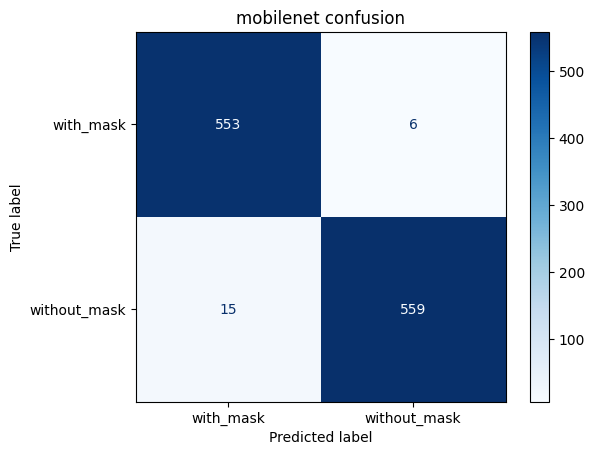

In [16]:
mob.load_state_dict(torch.load('best_mobilenet_mask.pt', map_location=device))
mob_pred, _ = predict(mob, mob_te_dl)
mob_acc = accuracy_score(y_te, mob_pred)
print('mobilenet test accuracy:', round(mob_acc, 4))
print(classification_report(y_te, mob_pred, target_names=classes))

ConfusionMatrixDisplay(confusion_matrix(y_te, mob_pred), display_labels=classes).plot(cmap='Blues')
plt.title('mobilenet confusion'); plt.show()

## comparison

In [17]:
cnn_rep = classification_report(y_te, cnn_pred, target_names=classes, output_dict=True)
mob_rep = classification_report(y_te, mob_pred, target_names=classes, output_dict=True)

cmp = pd.DataFrame({
    'test_acc':    [cnn_acc, mob_acc],
    'f1_with_mask':    [cnn_rep['with_mask']['f1-score'],    mob_rep['with_mask']['f1-score']],
    'f1_without_mask': [cnn_rep['without_mask']['f1-score'], mob_rep['without_mask']['f1-score']],
}, index=['cnn_scratch', 'mobilenetv2']).round(4)
print(cmp)

             test_acc  f1_with_mask  f1_without_mask
cnn_scratch    0.9568        0.9561           0.9574
mobilenetv2    0.9815        0.9814           0.9816


## end to end demo

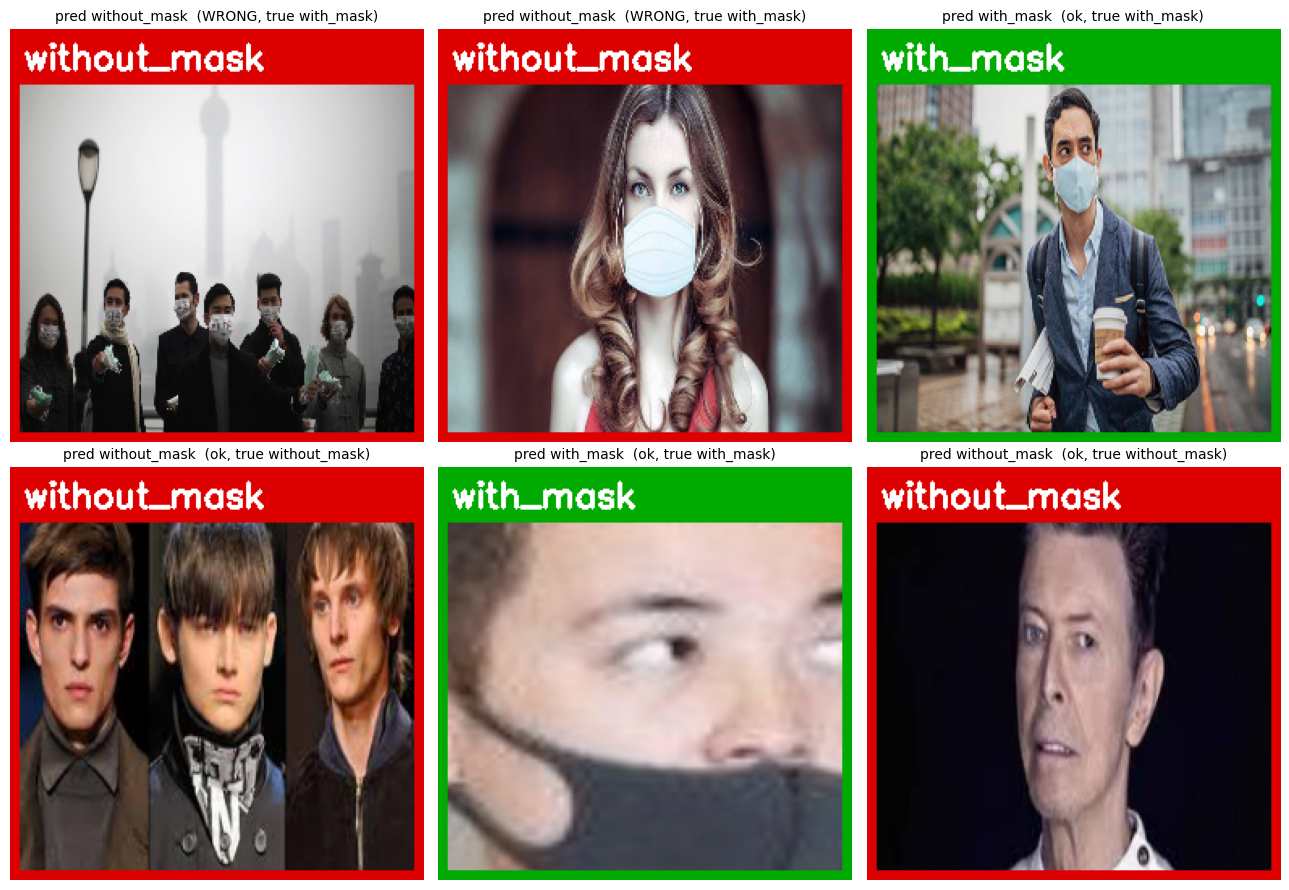

In [ ]:
wrong_idx = list(np.where(mob_pred != y_te)[0])
right_idx = list(np.where(mob_pred == y_te)[0])
random.shuffle(right_idx)
demo_idx = (wrong_idx[:2] + right_idx[:4])[:6]

def annotate(path, pred):
    img = np.array(Image.open(path).convert('RGB'))
    img = cv2.resize(img, (256, 256))
    color = (0, 170, 0) if pred == 0 else (220, 0, 0)   # green with_mask, red without
    cv2.rectangle(img, (0, 0), (255, 255), color, 10)
    cv2.rectangle(img, (0, 0), (255, 34), color, -1)
    cv2.putText(img, classes[pred], (8, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    return img

cols = 3; rows = int(np.ceil(len(demo_idx) / cols))
fig, ax = plt.subplots(rows, cols, figsize=(13, 4.5*rows))
ax = np.array(ax).ravel()
for k, idx in enumerate(demo_idx):
    p, y = test[idx]
    pred = mob_pred[idx]
    ax[k].imshow(annotate(p, pred))
    mark = 'ok' if pred == y else 'WRONG'
    ax[k].set_title(f'pred {classes[pred]}  ({mark}, true {classes[y]})', fontsize=10)
    ax[k].axis('off')
for k in range(len(demo_idx), len(ax)): ax[k].axis('off')
plt.tight_layout(); plt.show()

## wrap up

test set is 1133 held out images.

| model | test accuracy |
|---|---|
| cnn from scratch | 0.957 |
| mobilenetv2 transfer | 0.982 |
